# model training MLP vs GCN vs GAT (5-fold cross-validation)

In [5]:
%pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from dataset.dataset_util import load_esol, split_dataset, kfold_indices, make_loaders, get_fingerprints, rmse, mae, r_squared
from gnns.gnn_util import GCNModel, GATModel, run_training, get_predictions
from nn.nn_util import MLPModel, run_training_mlp, get_predictions_mlp

## data

In [7]:
dataset = load_esol(root='data/')
train_set, test_set = split_dataset(dataset, test_ratio=0.2, seed=42)

# graph loaders for GCN/GAT (full training set → final model; test for evaluation)
train_loader, test_loader = make_loaders(train_set, test_set, batch_size=64)

# fingerprints for MLP
X_train, y_train = get_fingerprints(train_set)
X_test, y_test = get_fingerprints(test_set)

# k-fold indices for cross-validation
K = 5
folds = kfold_indices(len(train_set), k=K, seed=42)

print(f'train: {len(train_set)}  test: {len(test_set)}  ({K}-fold CV on train set)')

train: 903  test: 225  (5-fold CV on train set)


In [8]:
LOAD_SAVED_WEIGHTS = False

if LOAD_SAVED_WEIGHTS:
    import json
    from pathlib import Path

    MODEL_DIR = Path('models')
    required = [MODEL_DIR / 'mlp.pt', MODEL_DIR / 'gcn.pt', MODEL_DIR / 'gat.pt', MODEL_DIR / 'cv_results.json']
    missing = [p for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError('missing ' + ', '.join(str(p) for p in missing) + ' — train and run the save cell first.')

    mlp = MLPModel(in_features=1024, hidden=128)
    mlp.load_state_dict(torch.load(MODEL_DIR / 'mlp.pt', map_location='cpu'))

    gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
    gcn.load_state_dict(torch.load(MODEL_DIR / 'gcn.pt', map_location='cpu'))

    gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
    gat.load_state_dict(torch.load(MODEL_DIR / 'gat.pt', map_location='cpu'))

    with open(MODEL_DIR / 'cv_results.json') as f:
        cv_results = json.load(f)
    mlp_cv = cv_results['mlp']
    gcn_cv = cv_results['gcn']
    gat_cv = cv_results['gat']
    mlp_fold_histories = cv_results.get('mlp_fold_histories', [])
    gcn_fold_histories = cv_results.get('gcn_fold_histories', [])
    gat_fold_histories = cv_results.get('gat_fold_histories', [])


## train MLP (5-fold CV + final model)

In [ ]:
mlp_cv = {'rmse': [], 'mae': [], 'r2': []}
mlp_fold_histories = []

print('MLP 5-fold cross-validation')
for fold_i, (tr_idx, vl_idx) in enumerate(folds):
    print(f'fold {fold_i+1}/{K}:')
    fold_train, fold_val = train_set[tr_idx], train_set[vl_idx]
    X_tr, y_tr = get_fingerprints(fold_train)
    X_vl, y_vl = get_fingerprints(fold_val)

    model_f = MLPModel(in_features=1024, hidden=128)
    hist = run_training_mlp(model_f, X_tr, y_tr, X_vl, y_vl, epochs=10000, lr=0.001, verbose=False)
    mlp_fold_histories.append(hist)

    preds = get_predictions_mlp(model_f, X_vl)
    fold_rmse = rmse(preds.squeeze(), y_vl.squeeze())
    fold_mae = mae(preds.squeeze(), y_vl.squeeze())
    fold_r2 = r_squared(preds.squeeze(), y_vl.squeeze())
    mlp_cv['rmse'].append(fold_rmse)
    mlp_cv['mae'].append(fold_mae)
    mlp_cv['r2'].append(fold_r2)
    print(f' RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R\u00b2: {fold_r2:.4f}')

print(f'\n RMSE: {np.mean(mlp_cv["rmse"]):.4f}  MAE: {np.mean(mlp_cv["mae"]):.4f}  R\u00b2: {np.mean(mlp_cv["r2"]):.4f}')

# final model on full training set
mlp = MLPModel(in_features=1024, hidden=128)
run_training_mlp(mlp, X_train, y_train, epochs=10000, lr=0.001, verbose=False)
print('final MLP trained on full training set')

MLP 5-fold cross-validation
--- fold 1/5 ---
  RMSE: 1.2347  MAE: 0.9578  R²: 0.6931
--- fold 2/5 ---
  RMSE: 1.1977  MAE: 0.8703  R²: 0.6718
--- fold 3/5 ---
  RMSE: 1.2634  MAE: 0.9252  R²: 0.6132
--- fold 4/5 ---
  RMSE: 1.3900  MAE: 1.0181  R²: 0.4809
--- fold 5/5 ---
  RMSE: 1.3148  MAE: 0.9681  R²: 0.5895

MLP CV average — RMSE: 1.2801  MAE: 0.9479  R²: 0.6097
final MLP trained on full training set


## train GCN (5-fold CV + final model)

In [ ]:
from torch_geometric.loader import DataLoader

gcn_cv = {'rmse': [], 'mae': [], 'r2': []}
gcn_fold_histories = []

print('GCN 5-fold cross-validation')
for fold_i, (tr_idx, vl_idx) in enumerate(folds):
    print(f'fold {fold_i+1}/{K}:')
    fold_train, fold_val = train_set[tr_idx], train_set[vl_idx]
    fold_tr_loader = DataLoader(fold_train, batch_size=64, shuffle=True)
    fold_vl_loader = DataLoader(fold_val, batch_size=64)

    model_f = GCNModel(in_channels=dataset.num_node_features, hidden=128)
    hist = run_training(model_f, fold_tr_loader, fold_vl_loader, epochs=10000, lr=0.001, verbose=False)
    gcn_fold_histories.append(hist)

    preds, targets = get_predictions(model_f, fold_vl_loader)
    fold_rmse = rmse(preds, targets)
    fold_mae = mae(preds, targets)
    fold_r2 = r_squared(preds, targets)
    gcn_cv['rmse'].append(fold_rmse)
    gcn_cv['mae'].append(fold_mae)
    gcn_cv['r2'].append(fold_r2)
    print(f' RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R\u00b2: {fold_r2:.4f}')

print(f'\nGCN CV average RMSE: {np.mean(gcn_cv["rmse"]):.4f}  MAE: {np.mean(gcn_cv["mae"]):.4f}  R\u00b2: {np.mean(gcn_cv["r2"]):.4f}')

# final model on full training set
gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
run_training(gcn, train_loader, epochs=10000, lr=0.001, verbose=False)
print('final GCN trained on full training set')

GCN 5-fold cross-validation
--- fold 1/5 ---
  RMSE: 0.9046  MAE: 0.6684  R²: 0.8353
--- fold 2/5 ---
  RMSE: 0.7663  MAE: 0.5726  R²: 0.8656
--- fold 3/5 ---
  RMSE: 0.7640  MAE: 0.5869  R²: 0.8586
--- fold 4/5 ---
  RMSE: 0.8324  MAE: 0.6374  R²: 0.8138
--- fold 5/5 ---
  RMSE: 0.8003  MAE: 0.6137  R²: 0.8479

GCN CV average — RMSE: 0.8135  MAE: 0.6158  R²: 0.8442
final GCN trained on full training set


## train GAT (5-fold CV + final model)

In [ ]:
gat_cv = {'rmse': [], 'mae': [], 'r2': []}
gat_fold_histories = []

print('GAT 5-fold cross-validation')
for fold_i, (tr_idx, vl_idx) in enumerate(folds):
    print(f'fold {fold_i+1}/{K}:')
    fold_train, fold_val = train_set[tr_idx], train_set[vl_idx]
    fold_tr_loader = DataLoader(fold_train, batch_size=64, shuffle=True)
    fold_vl_loader = DataLoader(fold_val, batch_size=64)

    model_f = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
    hist = run_training(model_f, fold_tr_loader, fold_vl_loader, epochs=10000, lr=0.001, verbose=False)
    gat_fold_histories.append(hist)

    preds, targets = get_predictions(model_f, fold_vl_loader)
    fold_rmse = rmse(preds, targets)
    fold_mae = mae(preds, targets)
    fold_r2 = r_squared(preds, targets)
    gat_cv['rmse'].append(fold_rmse)
    gat_cv['mae'].append(fold_mae)
    gat_cv['r2'].append(fold_r2)
    print(f' RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R\u00b2: {fold_r2:.4f}')

print(f'\nGAT CV average RMSE: {np.mean(gat_cv["rmse"]):.4f}  MAE: {np.mean(gat_cv["mae"]):.4f}  R\u00b2: {np.mean(gat_cv["r2"]):.4f}')

# final model on full training set
gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
run_training(gat, train_loader, epochs=10000, lr=0.001, verbose=False)
print('final GAT trained on full training set')

GAT 5-fold cross-validation
--- fold 1/5 ---
  RMSE: 0.9749  MAE: 0.7058  R²: 0.8087
--- fold 2/5 ---
  RMSE: 0.9461  MAE: 0.6593  R²: 0.7952
--- fold 3/5 ---
  RMSE: 0.8935  MAE: 0.6513  R²: 0.8065
--- fold 4/5 ---
  RMSE: 1.0167  MAE: 0.7263  R²: 0.7223
--- fold 5/5 ---
  RMSE: 0.8412  MAE: 0.6300  R²: 0.8319

GAT CV average — RMSE: 0.9345  MAE: 0.6746  R²: 0.7929
final GAT trained on full training set


## save trained models

In [12]:
import json
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

torch.save(mlp.state_dict(), MODEL_DIR / 'mlp.pt')
torch.save(gcn.state_dict(), MODEL_DIR / 'gcn.pt')
torch.save(gat.state_dict(), MODEL_DIR / 'gat.pt')
with open(MODEL_DIR / 'cv_results.json', 'w') as f:
    json.dump({
        'mlp': mlp_cv, 'gcn': gcn_cv, 'gat': gat_cv,
        'mlp_fold_histories': mlp_fold_histories,
        'gcn_fold_histories': gcn_fold_histories,
        'gat_fold_histories': gat_fold_histories,
    }, f)
print('saved to', MODEL_DIR.resolve())

saved to C:\Users\Bill\Github\molecular-solubility\models


## test evaluation

In [ ]:
mlp_cv_rmse, mlp_cv_mae, mlp_cv_r2 = np.mean(mlp_cv['rmse']), np.mean(mlp_cv['mae']), np.mean(mlp_cv['r2'])
gcn_cv_rmse, gcn_cv_mae, gcn_cv_r2 = np.mean(gcn_cv['rmse']), np.mean(gcn_cv['mae']), np.mean(gcn_cv['r2'])
gat_cv_rmse, gat_cv_mae, gat_cv_r2 = np.mean(gat_cv['rmse']), np.mean(gat_cv['mae']), np.mean(gat_cv['r2'])

print('5-fold CV averages')
print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"R\u00b2":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_cv_rmse:8.4f}  {mlp_cv_mae:8.4f}  {mlp_cv_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_cv_rmse:8.4f}  {gcn_cv_mae:8.4f}  {gcn_cv_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_cv_rmse:8.4f}  {gat_cv_mae:8.4f}  {gat_cv_r2:8.4f}')

# test set predictions (final models)
mlp_preds = get_predictions_mlp(mlp, X_test)
mlp_test_rmse = rmse(mlp_preds.squeeze(), y_test.squeeze())
mlp_test_mae = mae(mlp_preds.squeeze(), y_test.squeeze())
mlp_test_r2 = r_squared(mlp_preds.squeeze(), y_test.squeeze())

gcn_preds, gcn_targets = get_predictions(gcn, test_loader)
gcn_test_rmse = rmse(gcn_preds, gcn_targets)
gcn_test_mae = mae(gcn_preds, gcn_targets)
gcn_test_r2 = r_squared(gcn_preds, gcn_targets)

gat_preds, gat_targets = get_predictions(gat, test_loader)
gat_test_rmse = rmse(gat_preds, gat_targets)
gat_test_mae = mae(gat_preds, gat_targets)
gat_test_r2 = r_squared(gat_preds, gat_targets)

# thank you programming in science class for formatting 
print(f'\ntest set evaluation (final models)')
print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"R\u00b2":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_test_rmse:8.4f}  {mlp_test_mae:8.4f}  {mlp_test_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_test_rmse:8.4f}  {gcn_test_mae:8.4f}  {gcn_test_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_test_rmse:8.4f}  {gat_test_mae:8.4f}  {gat_test_r2:8.4f}')

print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"R\u00b2":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_test_rmse:8.4f}  {mlp_test_mae:8.4f}  {mlp_test_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_test_rmse:8.4f}  {gcn_test_mae:8.4f}  {gcn_test_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_test_rmse:8.4f}  {gat_test_mae:8.4f}  {gat_test_r2:8.4f}')

5-fold CV averages
model         RMSE       MAE        R²
--------------------------------------
MLP         1.2801    0.9479    0.6097
GCN         0.8135    0.6158    0.8442
GAT         0.9345    0.6746    0.7929

test set evaluation (final models)
model         RMSE       MAE        R²
--------------------------------------
MLP         1.1659    0.8639    0.7122
GCN         0.8849    0.6811    0.8342
GAT         0.8038    0.5944    0.8632
model         RMSE       MAE        R²
--------------------------------------
MLP         1.1659    0.8639    0.7122
GCN         0.8849    0.6811    0.8342
GAT         0.8038    0.5944    0.8632


## loss curves (averaged across folds)

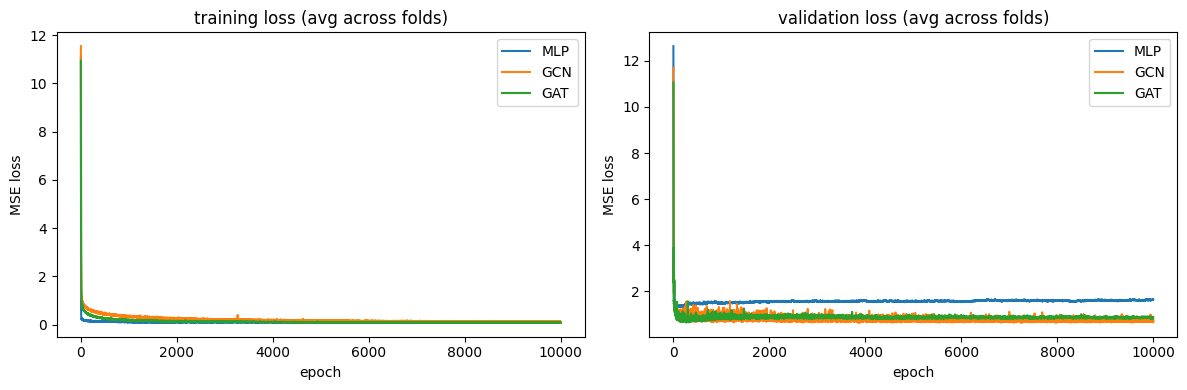

In [16]:
def avg_curve(fold_histories, key):
    arrays = [np.array(h[key]) for h in fold_histories if key in h]
    min_len = min(len(a) for a in arrays)
    return np.mean([a[:min_len] for a in arrays], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(avg_curve(mlp_fold_histories, 'train_loss'), label='MLP')
ax1.plot(avg_curve(gcn_fold_histories, 'train_loss'), label='GCN')
ax1.plot(avg_curve(gat_fold_histories, 'train_loss'), label='GAT')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE loss')
ax1.set_title('training loss (avg across folds)')
ax1.legend()

ax2.plot(avg_curve(mlp_fold_histories, 'val_loss'), label='MLP')
ax2.plot(avg_curve(gcn_fold_histories, 'val_loss'), label='GCN')
ax2.plot(avg_curve(gat_fold_histories, 'val_loss'), label='GAT')
ax2.set_xlabel('epoch')
ax2.set_ylabel('MSE loss')
ax2.set_title('validation loss (avg across folds)')
ax2.legend()

plt.tight_layout()
plt.show()

## predicted vs actual

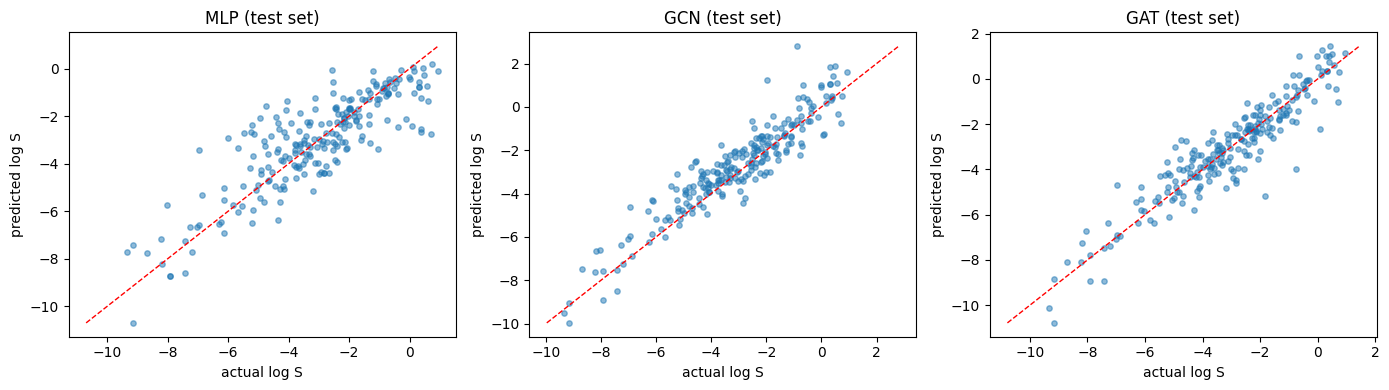

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_preds = [
    (mlp_preds.squeeze().detach().numpy(), y_test.squeeze().numpy(), 'MLP'),
    (gcn_preds.detach().numpy(), gcn_targets.detach().numpy(), 'GCN'),
    (gat_preds.detach().numpy(), gat_targets.detach().numpy(), 'GAT'),
]

for ax, (p, t, name) in zip(axes, all_preds):
    ax.scatter(t, p, alpha=0.5, s=15)
    lo = min(t.min(), p.min())
    hi = max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('actual log S')
    ax.set_ylabel('predicted log S')
    ax.set_title(f'{name} (test set)')

plt.tight_layout()
plt.show()

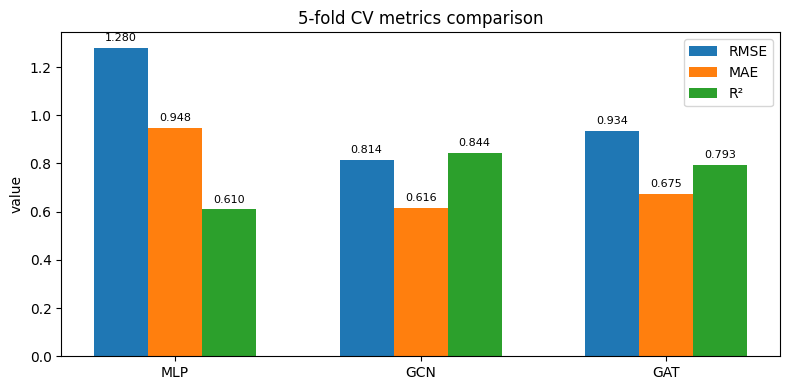

percentage improvement over MLP baseline (CV averages)
metric           GCN         GAT
--------------------------------
RMSE           36.4%       27.0%
MAE            35.0%       28.8%
R²             60.1%       46.9%


In [18]:
model_names = ['MLP', 'GCN', 'GAT']
rmse_vals = [mlp_cv_rmse, gcn_cv_rmse, gat_cv_rmse]
mae_vals = [mlp_cv_mae, gcn_cv_mae, gat_cv_mae]
r2_vals = [mlp_cv_r2, gcn_cv_r2, gat_cv_r2]

x = np.arange(3)
width = 0.22

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, rmse_vals, width, label='RMSE')
ax.bar(x,         mae_vals,  width, label='MAE')
ax.bar(x + width, r2_vals,   width, label='R\u00b2')

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('value')
ax.set_title('5-fold CV metrics comparison')
ax.legend()

for i, (r, m, r2) in enumerate(zip(rmse_vals, mae_vals, r2_vals)):
    ax.text(i - width, r + 0.02, f'{r:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i,         m + 0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width, r2 + 0.02, f'{r2:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

rmse_improv_gcn = (mlp_cv_rmse - gcn_cv_rmse) / mlp_cv_rmse * 100
rmse_improv_gat = (mlp_cv_rmse - gat_cv_rmse) / mlp_cv_rmse * 100
mae_improv_gcn = (mlp_cv_mae - gcn_cv_mae) / mlp_cv_mae * 100
mae_improv_gat = (mlp_cv_mae - gat_cv_mae) / mlp_cv_mae * 100
r2_improv_gcn = (gcn_cv_r2 - mlp_cv_r2) / (1 - mlp_cv_r2) * 100
r2_improv_gat = (gat_cv_r2 - mlp_cv_r2) / (1 - mlp_cv_r2) * 100

print('percentage improvement over MLP baseline (CV averages)')
print(f'{"metric":<8s}  {"GCN":>10s}  {"GAT":>10s}')
print(f'{"-"*32}')
print(f'{"RMSE":<8s}  {rmse_improv_gcn:>9.1f}%  {rmse_improv_gat:>9.1f}%')
print(f'{"MAE":<8s}  {mae_improv_gcn:>9.1f}%  {mae_improv_gat:>9.1f}%')
print(f'{"R\u00b2":<8s}  {r2_improv_gcn:>9.1f}%  {r2_improv_gat:>9.1f}%')

## error distribution

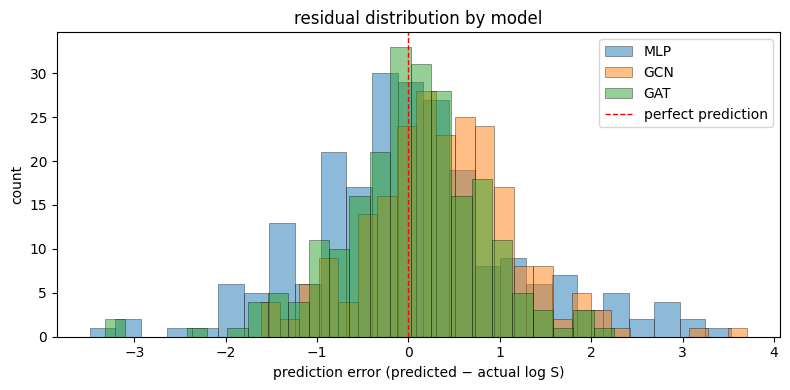

In [19]:
mlp_residuals = (mlp_preds.squeeze() - y_test.squeeze()).detach().numpy()
gcn_residuals = (gcn_preds - gcn_targets).detach().numpy()
gat_residuals = (gat_preds - gat_targets).detach().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mlp_residuals, bins=25, alpha=0.5, label='MLP', edgecolor='black', linewidth=0.5)
ax.hist(gcn_residuals, bins=25, alpha=0.5, label='GCN', edgecolor='black', linewidth=0.5)
ax.hist(gat_residuals, bins=25, alpha=0.5, label='GAT', edgecolor='black', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='perfect prediction')
ax.set_xlabel('prediction error (predicted \u2212 actual log S)')
ax.set_ylabel('count')
ax.set_title('residual distribution by model')
ax.legend()
plt.tight_layout()
plt.show()

## best and worst predictions (GAT)

In [20]:
import pandas as pd

smiles_list = [data.smiles for data in test_set]
gat_errors = (gat_preds - gat_targets).abs()

sorted_idx = gat_errors.argsort()
best_idx = sorted_idx[:5].tolist()
worst_idx = sorted_idx[-5:].flip(0).tolist()

def build_table(indices):
    rows = []
    for i in indices:
        rows.append({
            'SMILES': smiles_list[i],
            'Actual log S': f'{gat_targets[i].item():.3f}',
            'GAT Predicted': f'{gat_preds[i].item():.3f}',
            'Absolute Error': f'{gat_errors[i].item():.3f}',
        })
    return pd.DataFrame(rows)

print('5 best GAT predictions (lowest error)')
display(build_table(best_idx))
print()
print('5 worst GAT predictions (highest error)')
display(build_table(worst_idx))

5 best GAT predictions (lowest error)


,SMILES,Actual log S,GAT Predicted,Absolute Error
0,C=CCCC=C,-2.680,-2.679,0.001
1,CCCC(=O)OCC,-1.360,-1.361,0.001
2,CCCC1C(=O)N3N(C1=O)c2cc(C)ccc2N=C3N(C)C,-3.538,-3.545,0.007
3,C/C=C/C=O,0.320,0.328,0.008
4,CC=CC=O,0.320,0.328,0.008



5 worst GAT predictions (highest error)


,SMILES,Actual log S,GAT Predicted,Absolute Error
0,CC2(C)C1CCC(C)(C1)C2=O,-1.850,-5.169,3.319
1,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,-3.996,3.226
2,NNc1ccccc1,0.070,-2.200,2.270
3,CCCCC(CC)COC(=O)c1ccccc1C(=O)OCC(CC)CCCC,-6.960,-4.710,2.250
4,CCOC(=O)c1cncn1C(C)c2ccccc2,-4.735,-2.718,2.017


## export results

In [21]:
%pip install openpyxl -q

import pandas as pd

cv_summary_df = pd.DataFrame({
    'Model': ['MLP', 'GCN', 'GAT'],
    'CV RMSE': [mlp_cv_rmse, gcn_cv_rmse, gat_cv_rmse],
    'CV MAE': [mlp_cv_mae, gcn_cv_mae, gat_cv_mae],
    'CV R\u00b2': [mlp_cv_r2, gcn_cv_r2, gat_cv_r2],
    'Test RMSE': [mlp_test_rmse, gcn_test_rmse, gat_test_rmse],
    'Test MAE': [mlp_test_mae, gcn_test_mae, gat_test_mae],
    'Test R\u00b2': [mlp_test_r2, gcn_test_r2, gat_test_r2],
})

smiles_list = [data.smiles for data in test_set]
predictions_df = pd.DataFrame({
    'SMILES': smiles_list,
    'Actual log S': gat_targets.detach().numpy(),
    'MLP Predicted': mlp_preds.squeeze().detach().numpy(),
    'GCN Predicted': gcn_preds.detach().numpy(),
    'GAT Predicted': gat_preds.detach().numpy(),
})

with pd.ExcelWriter('results.xlsx', engine='openpyxl') as writer:
    cv_summary_df.to_excel(writer, sheet_name='Summary Metrics', index=False)
    predictions_df.to_excel(writer, sheet_name='Test Predictions', index=False)

print(f'saved results.xlsx ({len(predictions_df)} test molecules, 2 sheets)')

Note: you may need to restart the kernel to use updated packages.
saved results.xlsx (225 test molecules, 2 sheets)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
